In [58]:
# forçando o repositorio a encontrar src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [59]:

import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analytics.Plot3d import Plot3d
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.x13 import x13_arima_analysis


In [60]:
data_path = os.path.join('..','data', 'raw', 'dados_completos.csv')
df = pd.read_csv(data_path)
df

,data,4393,21084,24369,27640,4390,24364,433,29037
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309,0.21,36.87
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205,0.64,36.99
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478,0.36,37.21
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945,0.08,37.42
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078,0.88,49.86
169,2026-04-01,121.06,5.51,5.8,2.36,1.09,110.95732,0.67,49.87
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587,0.58,49.83
171,2026-06-01,124.07,5.57,5.4,2.37,1.12,NaN,0.16,NaN


4393	Índice de Confiança do Consumidor 

21084	Inadimplência da carteira de crédito - Pessoas físicas - Total 

24369	Taxa de desocupação - PNADC 

27640 - 27640	Taxa média mensal de juros das operações de crédito não rotativo - Pessoas físicas - Total 

4390 - selic 


24364	Índice de Atividade Econômica do Banco Central (IBC-Br) - com ajuste sazonal



In [61]:
df = df.rename(columns={'4393': 'Confiança_consumidor', 
                        '21084':'Inadimplencia_PF', 
                        '24369':'Desemprego',
                        '27640':'Juros_nao_rotativos_PF',
                        '4390':'SELIC', 
                        '24364':'IBC-Br',
                        '433':'IPCA', 
                        '29037':'Endividamento_das_familias'})
df

,data,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309,0.21,36.87
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205,0.64,36.99
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478,0.36,37.21
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945,0.08,37.42
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078,0.88,49.86
169,2026-04-01,121.06,5.51,5.8,2.36,1.09,110.95732,0.67,49.87
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587,0.58,49.83
171,2026-06-01,124.07,5.57,5.4,2.37,1.12,NaN,0.16,NaN


In [62]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data                        173 non-null    datetime64[us]
 1   Confiança_consumidor        173 non-null    float64       
 2   Inadimplencia_PF            172 non-null    float64       
 3   Desemprego                  172 non-null    float64       
 4   Juros_nao_rotativos_PF      172 non-null    float64       
 5   SELIC                       173 non-null    float64       
 6   IBC-Br                      171 non-null    float64       
 7   IPCA                        172 non-null    float64       
 8   Endividamento_das_familias  171 non-null    float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 12.3 KB


In [63]:
df = df.set_index('data')
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309,0.21,36.87
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205,0.64,36.99
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478,0.36,37.21
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945,0.08,37.42
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...,...
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078,0.88,49.86
2026-04-01,121.06,5.51,5.8,2.36,1.09,110.95732,0.67,49.87
2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587,0.58,49.83


In [64]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Confiança_consumidor,173.0,118.075665,17.985873,84.55000,106.860000,114.23000,127.05000,165.85000
Inadimplencia_PF,172.0,4.016221,0.648945,2.89000,3.622500,3.93500,4.25000,5.62000
Desemprego,172.0,9.595349,2.834949,5.10000,7.075000,8.75000,12.10000,14.90000
Juros_nao_rotativos_PF,172.0,1.869419,0.209365,1.43000,1.720000,1.84500,2.01000,2.37000
SELIC,173.0,0.780231,0.299653,0.13000,0.540000,0.82000,1.04000,1.28000
IBC-Br,171.0,99.803206,5.169938,83.03874,96.224275,99.51646,102.85532,111.03587
IPCA,172.0,0.466919,0.370008,-0.68000,0.240000,0.43000,0.67000,1.62000
Endividamento_das_familias,171.0,42.445380,4.787468,36.87000,38.295000,40.09000,48.19000,49.93000


In [65]:
df.isnull().sum()

Confiança_consumidor          0
Inadimplencia_PF              1
Desemprego                    1
Juros_nao_rotativos_PF        1
SELIC                         0
IBC-Br                        2
IPCA                          1
Endividamento_das_familias    2
dtype: int64

In [66]:
df = df.dropna()
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309,0.21,36.87
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205,0.64,36.99
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478,0.36,37.21
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945,0.08,37.42
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...,...
2026-01-01,127.39,5.38,5.4,2.33,1.16,110.05486,0.33,49.93
2026-02-01,127.39,5.56,5.8,2.30,1.00,110.65892,0.70,49.83
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078,0.88,49.86


C:\Users\souza\AppData\Local\Temp\ipykernel_13488\3660636175.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


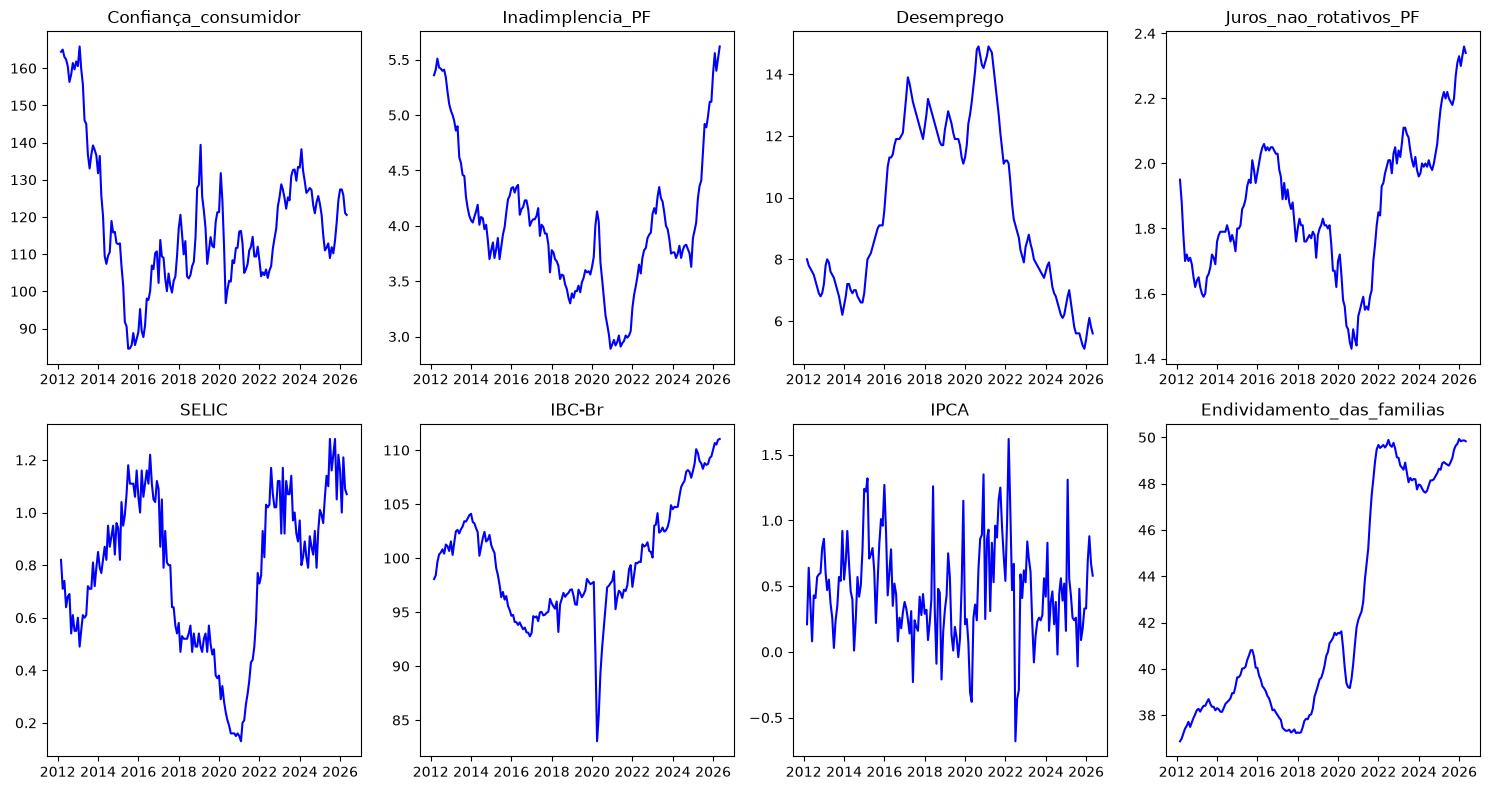

In [67]:
# plotando series agrupadas
fig, ax = plt.subplots(2, 4, figsize=(15,8))
for num, axes in zip(df.columns, ax.ravel()):
    axes.plot(df[num], color='blue')
    axes.set_title(f'{num}')
    fig.tight_layout()
    fig.show()


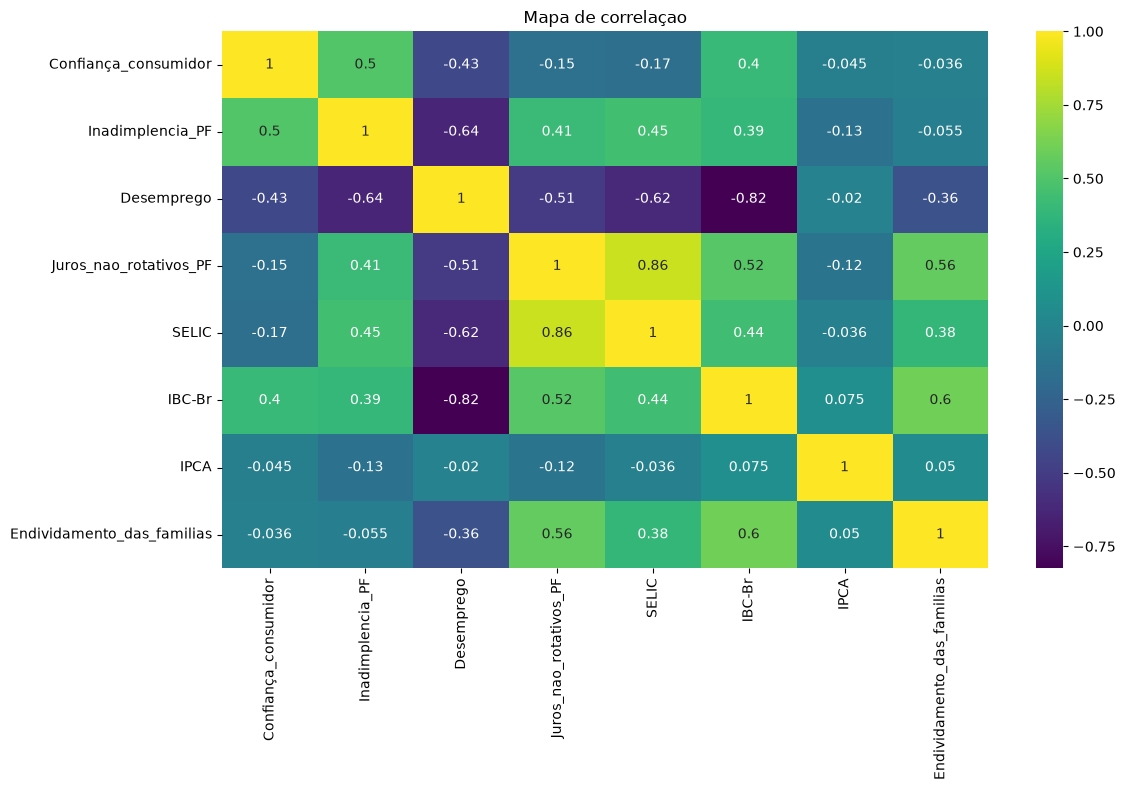

In [68]:
# calculando e plotando correlaçoes
corr = df.corr()
plt.figure(figsize=(12,8))
plt.title('Mapa de correlaçao')
sns.heatmap(corr, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()


In [69]:
df.columns

Index(['Confiança_consumidor', 'Inadimplencia_PF', 'Desemprego',
       'Juros_nao_rotativos_PF', 'SELIC', 'IBC-Br', 'IPCA',
       'Endividamento_das_familias'],
      dtype='str')

C:\Users\souza\AppData\Local\Temp\ipykernel_13488\2314505220.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


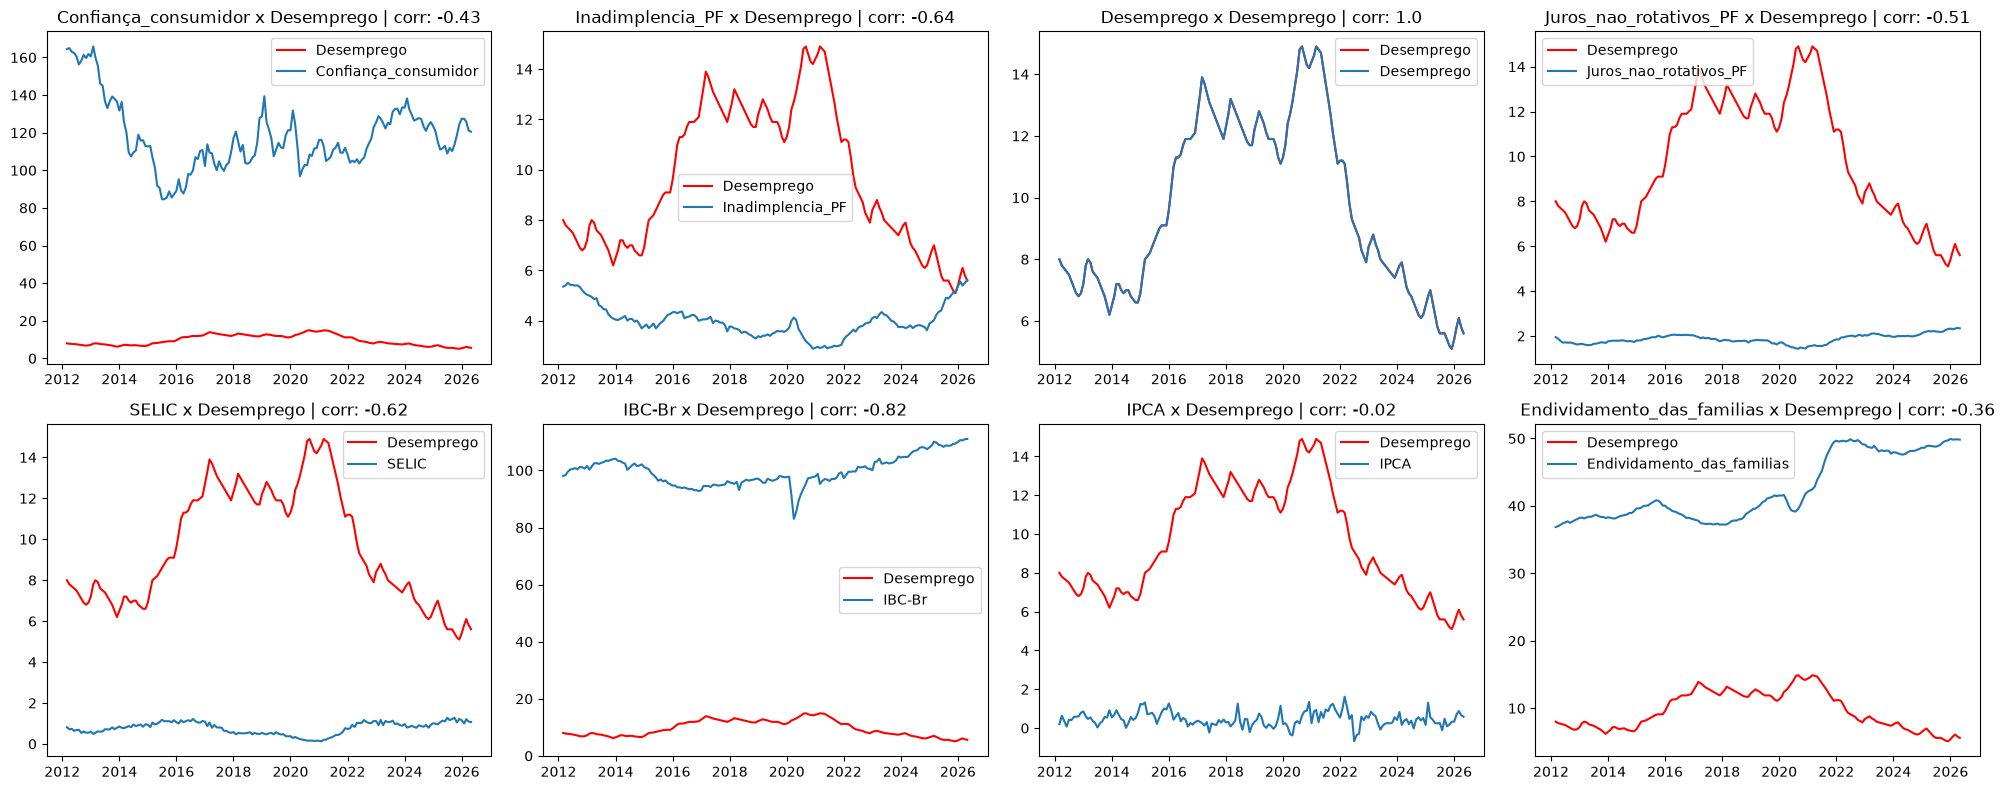

In [70]:
# relacionando taxas com o desemprego 
desemprego = df['Desemprego']
corr_desemprego = df.corr()['Desemprego']
fig, ax = plt.subplots(2, 4, figsize=(20,8))
for i, axes, corr in zip(df.columns, ax.ravel(), corr_desemprego):
    axes.plot(desemprego, color='red', label='Desemprego')
    axes.plot(df[i],label=f'{i}')
    axes.set_title(f'{i} x Desemprego | corr: {round(corr, 2)}')
    fig.tight_layout()
    axes.legend()
    fig.show()

In [71]:
fig = Plot3d(df['Desemprego'], y=df['SELIC'], z=df['Inadimplencia_PF'], title='Area de inadimplencia gerada por Desemprego e Selic')
fig.plot_surface()

-- Conseguimos enxergar clara evidencia de geraçao de area. O desemprego cai -> selic controla -> menos inadimplencia.

**NAO é causal, mas podemos enxergar boa relaçao entre essas caracteristicas** 

Nesse caso, a SELIC não é a vilã da historia, mas sim o amortecedor dessas relaçoes. 

Mesmo em alguns pontos mostrando relaçoes bem defidas, tambem vemos bastante disperçao no grafico ao lado, mostrando que não é um problema linear simples. 


In [72]:
fig_ibc = Plot3d(df['IBC-Br'], y=df['SELIC'], z=df['Inadimplencia_PF'], title='Area de inadimplencia gerada por IBC-Br e Selic')
fig_ibc.plot_surface()

essa nova Área gerada pelo IBC-br parece mais concentrada, mesmo nao afirmando relaçao monotonica. 

In [73]:
fig_desemprego = Plot3d(df['IBC-Br'], y=df['SELIC'], z=df['Desemprego'], title='Area de desemprego gerada por IBC-Br e Selic')
fig_desemprego.plot_surface()

As 3 variaveis apresentam comportamento quase linear ao olhar. O IBC-Br funciona como termometro e a selic como amortecedor. quando o ibc cai, a selic acompanha para segurar o desemprego. 

Relacionando com o grafico passado, onde o desemprego teve relações parecidas com a inadimplencia, isso mostra uma possivel existencia de relaçao 4d entre elas

**Reforçando que as analises nao confirmam causalidade economica**

In [74]:
# teste de estacionaridade 
for fuller_test in df.columns:
    p_value = adfuller(df[fuller_test], regression='c')[1]
    print(f'coluna: {fuller_test}')
    if p_value >0.05:
        print("a serie não é estacionaria")
    print()
    

coluna: Confiança_consumidor

coluna: Inadimplencia_PF
a serie não é estacionaria

coluna: Desemprego
a serie não é estacionaria

coluna: Juros_nao_rotativos_PF
a serie não é estacionaria

coluna: SELIC
a serie não é estacionaria

coluna: IBC-Br
a serie não é estacionaria

coluna: IPCA

coluna: Endividamento_das_familias
a serie não é estacionaria



C:\Users\souza\AppData\Local\Temp\ipykernel_13488\2978837369.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


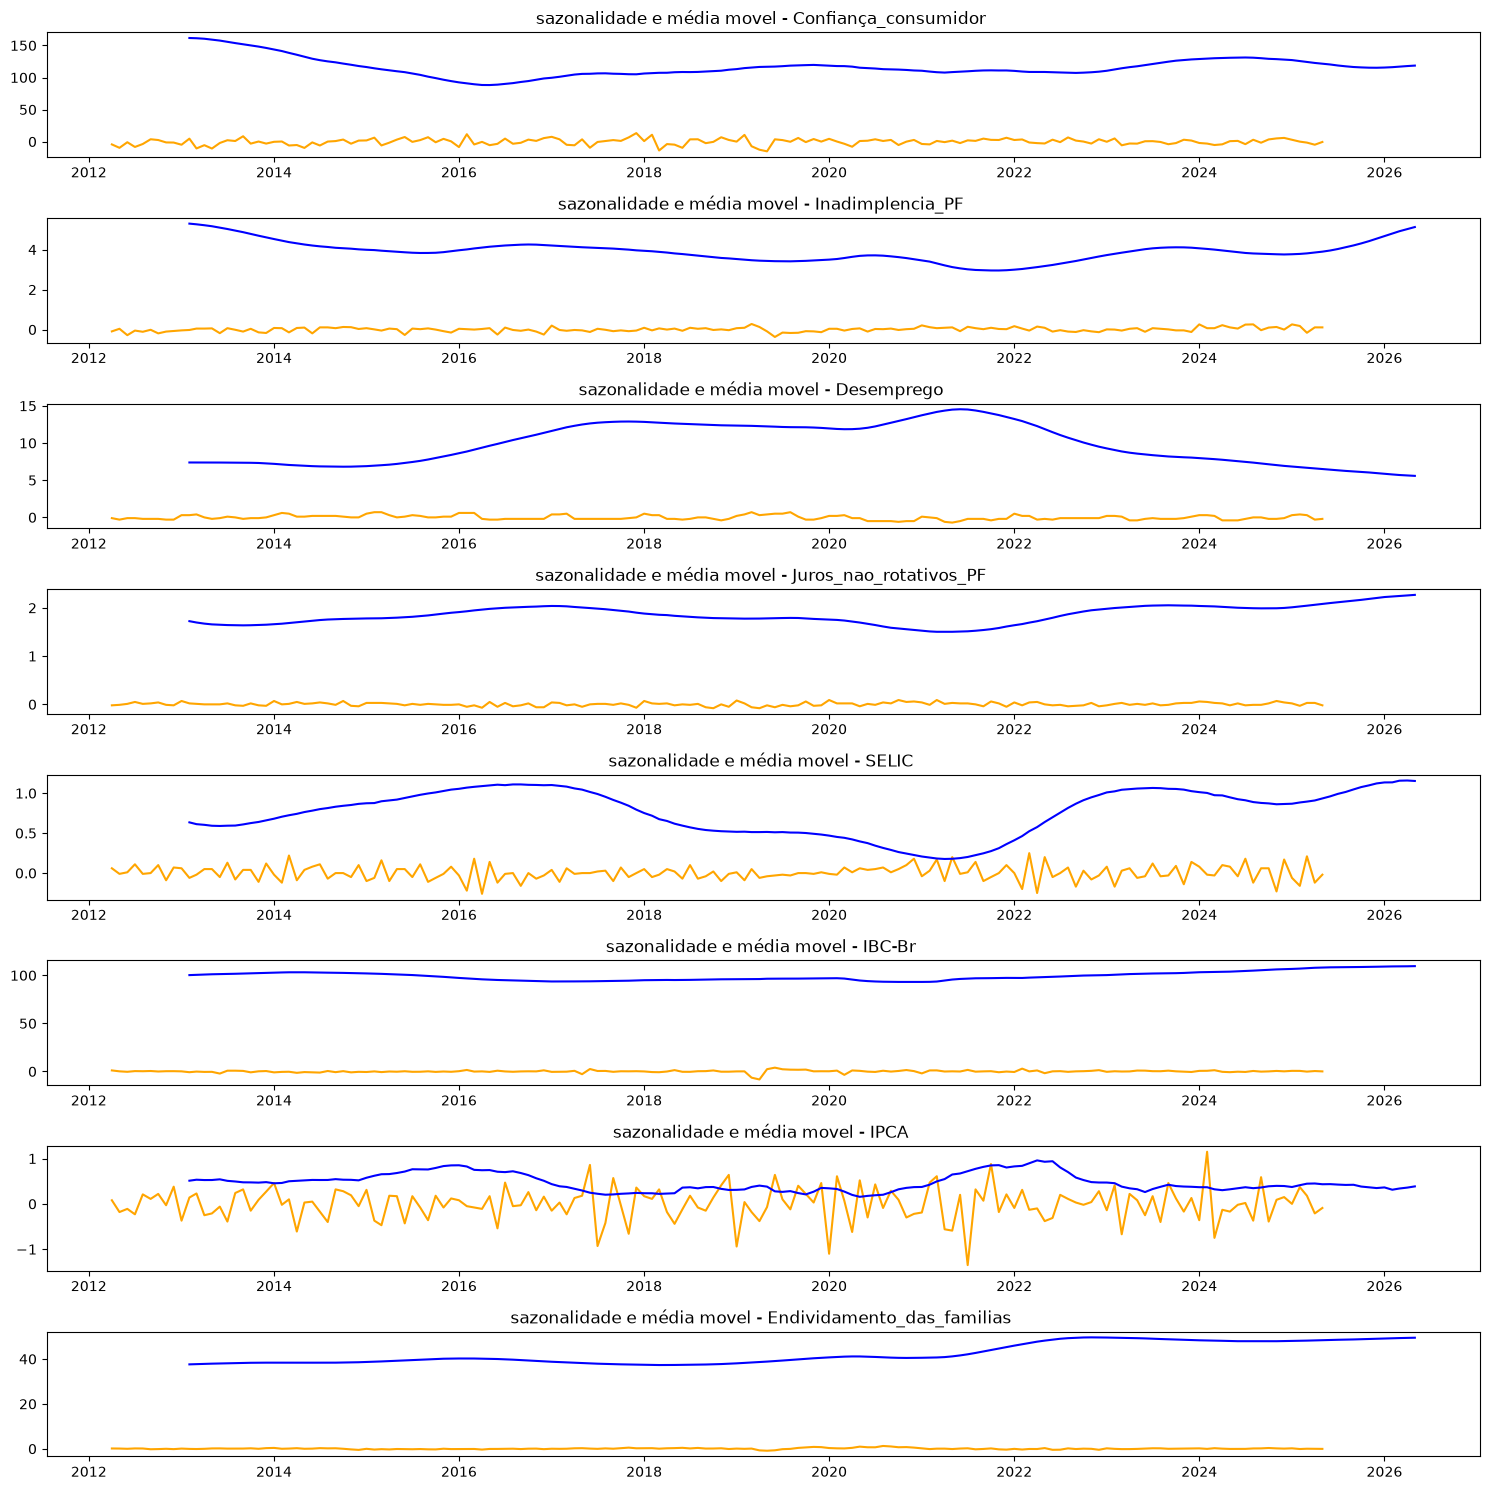

In [75]:
# sazonalidade e media movel 
fig, axes = plt.subplots(df.shape[1], 1, figsize=(15, 15))
for sazo, ax in zip(df.columns, axes.ravel()):
    sazo_ = df[sazo].shift(-12).diff()
    mavg = df[sazo].rolling(12).mean()
    ax.plot(sazo_, color='orange', label='Sazonalidade')
    ax.plot(mavg, color='blue', label='Média movel')
    ax.set_title(f'sazonalidade e média movel - {sazo} ')
    fig.tight_layout()
    fig.show()


In [76]:
# verificando multicolinearidade
X = df.drop('Inadimplencia_PF', axis=1)
X = sm.add_constant(X)
vif_df = pd.DataFrame()
vif_df['features'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,features,VIF
0,const,2341.303387
1,Confiança_consumidor,2.052959
2,Desemprego,7.418926
3,Juros_nao_rotativos_PF,6.339851
4,SELIC,7.836477
5,IBC-Br,6.293837
6,IPCA,1.112625
7,Endividamento_das_familias,2.203660


In [77]:
# separando em treino e teste para rodar no MQO
X_train = df.loc['2012-03-01':'2026-01-01']
y = df['Inadimplencia_PF']
y_train = y.loc['2012-03-01':'2026-01-01']

In [78]:
X_train

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309,0.21,36.87
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205,0.64,36.99
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478,0.36,37.21
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945,0.08,37.42
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...,...
2025-09-01,110.20,4.89,5.6,2.18,1.22,108.63642,0.48,49.11
2025-10-01,113.63,4.99,5.4,2.20,1.28,108.71590,0.09,49.46
2025-11-01,118.65,5.12,5.2,2.27,1.05,109.27405,0.18,49.64


In [79]:
y_train

data
2012-03-01    5.36
2012-04-01    5.41
2012-05-01    5.51
2012-06-01    5.43
2012-07-01    5.42
              ... 
2025-09-01    4.89
2025-10-01    4.99
2025-11-01    5.12
2025-12-01    5.12
2026-01-01    5.38
Name: Inadimplencia_PF, Length: 167, dtype: float64

In [80]:
#y_train = y_train.reset_index(drop=True)
#y_train

In [81]:
y_train

data
2012-03-01    5.36
2012-04-01    5.41
2012-05-01    5.51
2012-06-01    5.43
2012-07-01    5.42
              ... 
2025-09-01    4.89
2025-10-01    4.99
2025-11-01    5.12
2025-12-01    5.12
2026-01-01    5.38
Name: Inadimplencia_PF, Length: 167, dtype: float64

In [82]:
""""
# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem 
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""


'"\n# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem \nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

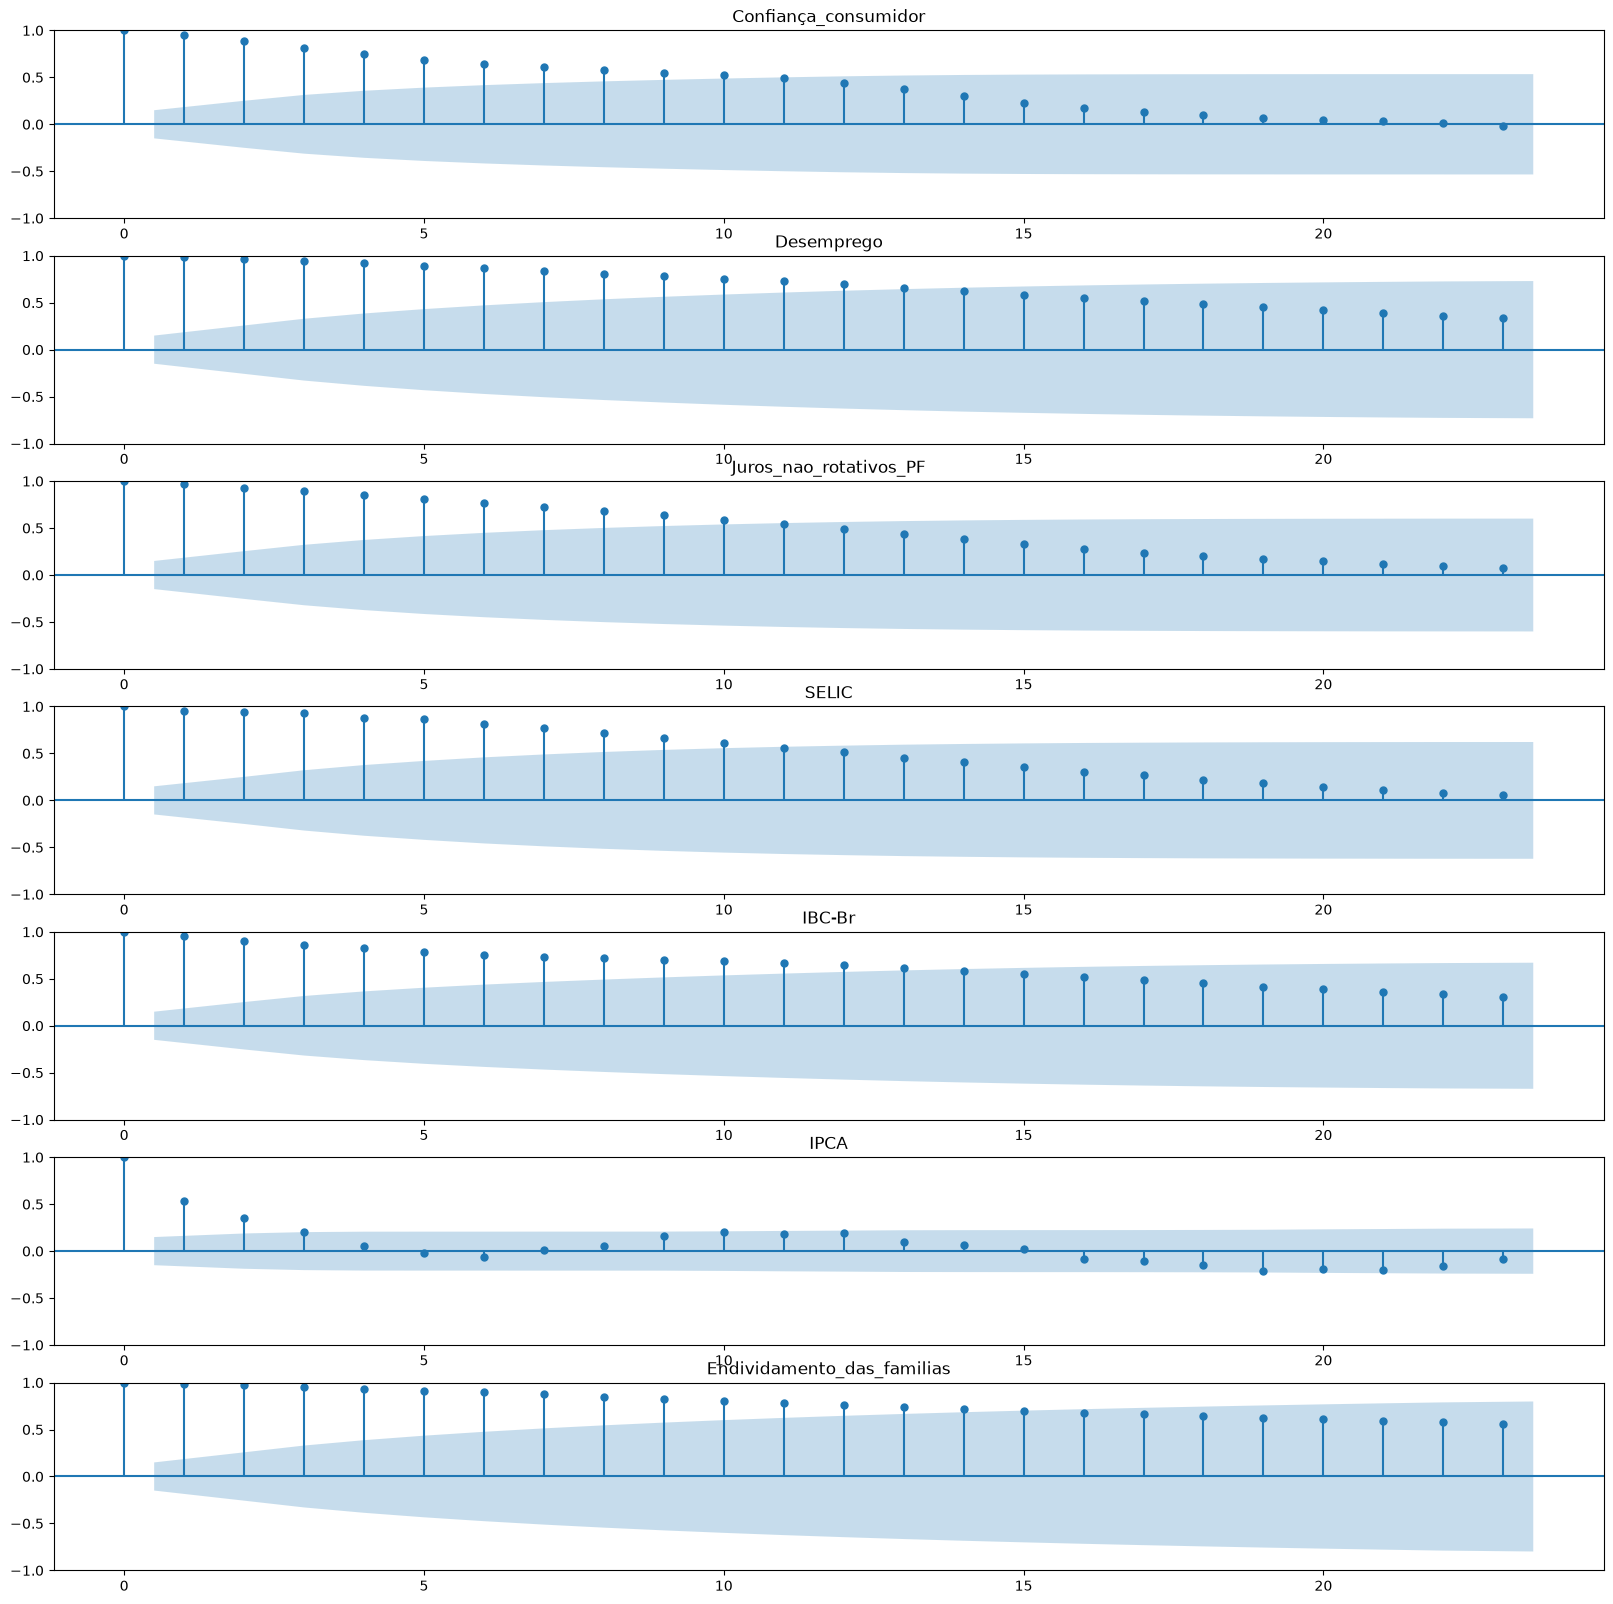

In [83]:
X_acf = X.drop('const', axis=1)
fig, axes = plt.subplots(X_acf.shape[1], 1, figsize=(20,20))
for acf, ax in zip(X_acf.columns, axes):
    sm.graphics.tsa.plot_acf(X_acf[acf], ax=ax)
    ax.set_title(f'{acf}')

In [84]:
# aplicando defasagens para testes 
X_train['Juros_nao_rotativos_PF_lag12'] = X_train['Juros_nao_rotativos_PF'].shift(12)
X_train['SELIC_lag12'] = X_train['SELIC'].shift(12)
X_train['PANDEMIA'] = np.where((X_train.index >= '2020-03-01')&(X_train.index <='2023-04-01'), 1,0)
# X_train = X_train.dropna()


In [85]:
""""
# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem 
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""

'"\n# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem \nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

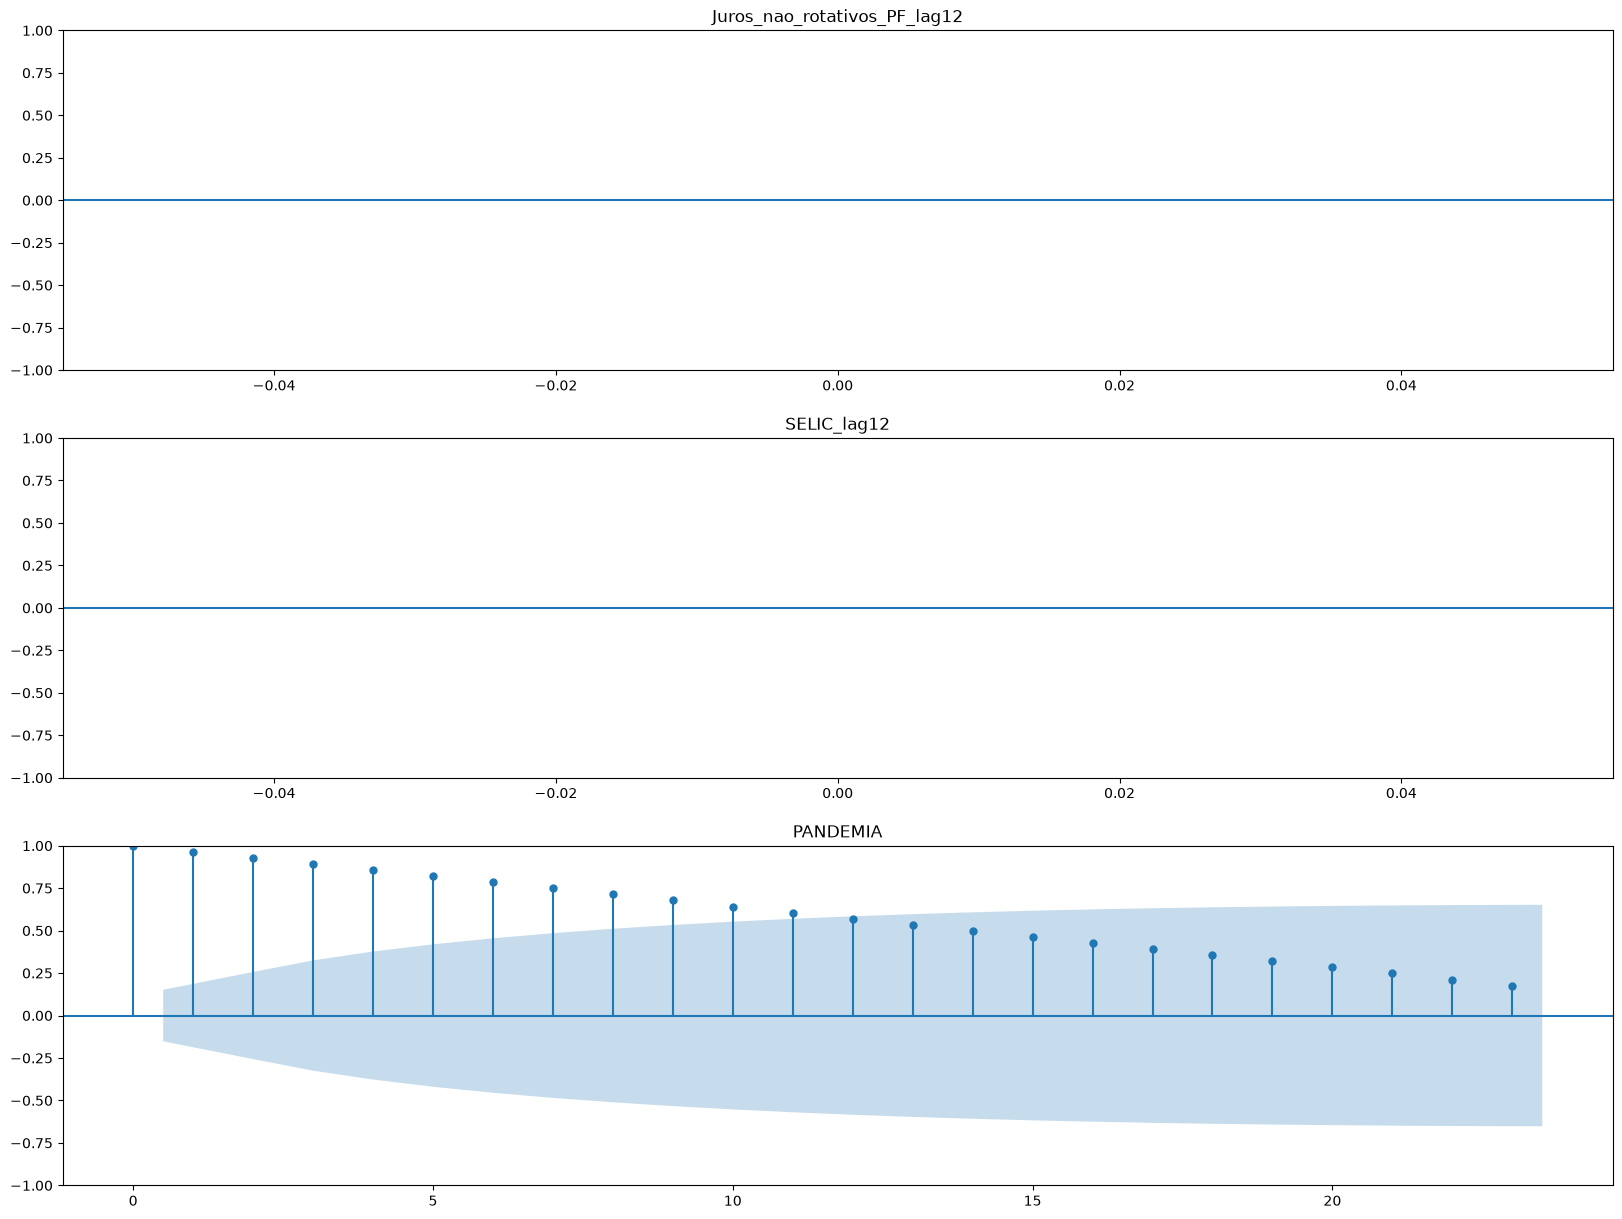

In [86]:
cols_acf = ['Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA']
fig, axes = plt.subplots(len(cols_acf), 1, figsize=(20,15))
for i, ax, in zip(cols_acf, axes):
    sm.graphics.tsa.plot_acf(X_train[i], ax=ax)
    ax.set_title(f'{i}')


nao ouve mudança significativa nas defasagens das variaveis. Mostrando assim que a persistencia é maior do que imaginavamos.

In [87]:
""""
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF', 'Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""

'"\nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\', \'Juros_nao_rotativos_PF_lag12\', \'SELIC_lag12\', \'PANDEMIA\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

X-13 ARIMA SEATS

Irei fazer uso do modelo X-13 ARIMA SEATS para tratar sazonalidadas presentes em nossos dados. 

In [88]:
X_train = X_train.drop(['Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA', 'Inadimplencia_PF'], axis=1)

In [89]:
X_train

,Confiança_consumidor,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,,
2012-03-01,164.42,8.0,1.95,0.82,98.06309,0.21,36.87
2012-04-01,164.99,7.8,1.88,0.71,98.38205,0.64,36.99
2012-05-01,163.05,7.7,1.78,0.74,99.62478,0.36,37.21
2012-06-01,162.35,7.6,1.70,0.64,100.33945,0.08,37.42
2012-07-01,160.56,7.5,1.72,0.68,100.51105,0.43,37.54
...,...,...,...,...,...,...,...
2025-09-01,110.20,5.6,2.18,1.22,108.63642,0.48,49.11
2025-10-01,113.63,5.4,2.20,1.28,108.71590,0.09,49.46
2025-11-01,118.65,5.2,2.27,1.05,109.27405,0.18,49.64


coluna Confiança_consumidor OK
coluna Desemprego OK
coluna Juros_nao_rotativos_PF OK


c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia\.env\Lib\site-packages\statsmodels\tsa\x13.py:192: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in one or more of the estimated spectra.
  warn(errors, X13Warning)


coluna SELIC OK


c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia\.env\Lib\site-packages\statsmodels\tsa\x13.py:192: X13Warning: WARNING: Automatic transformation selection cannot be done on a
          series with zero or negative values.
  warn(errors, X13Warning)


coluna IPCA OK
coluna Endividamento_das_familias OK


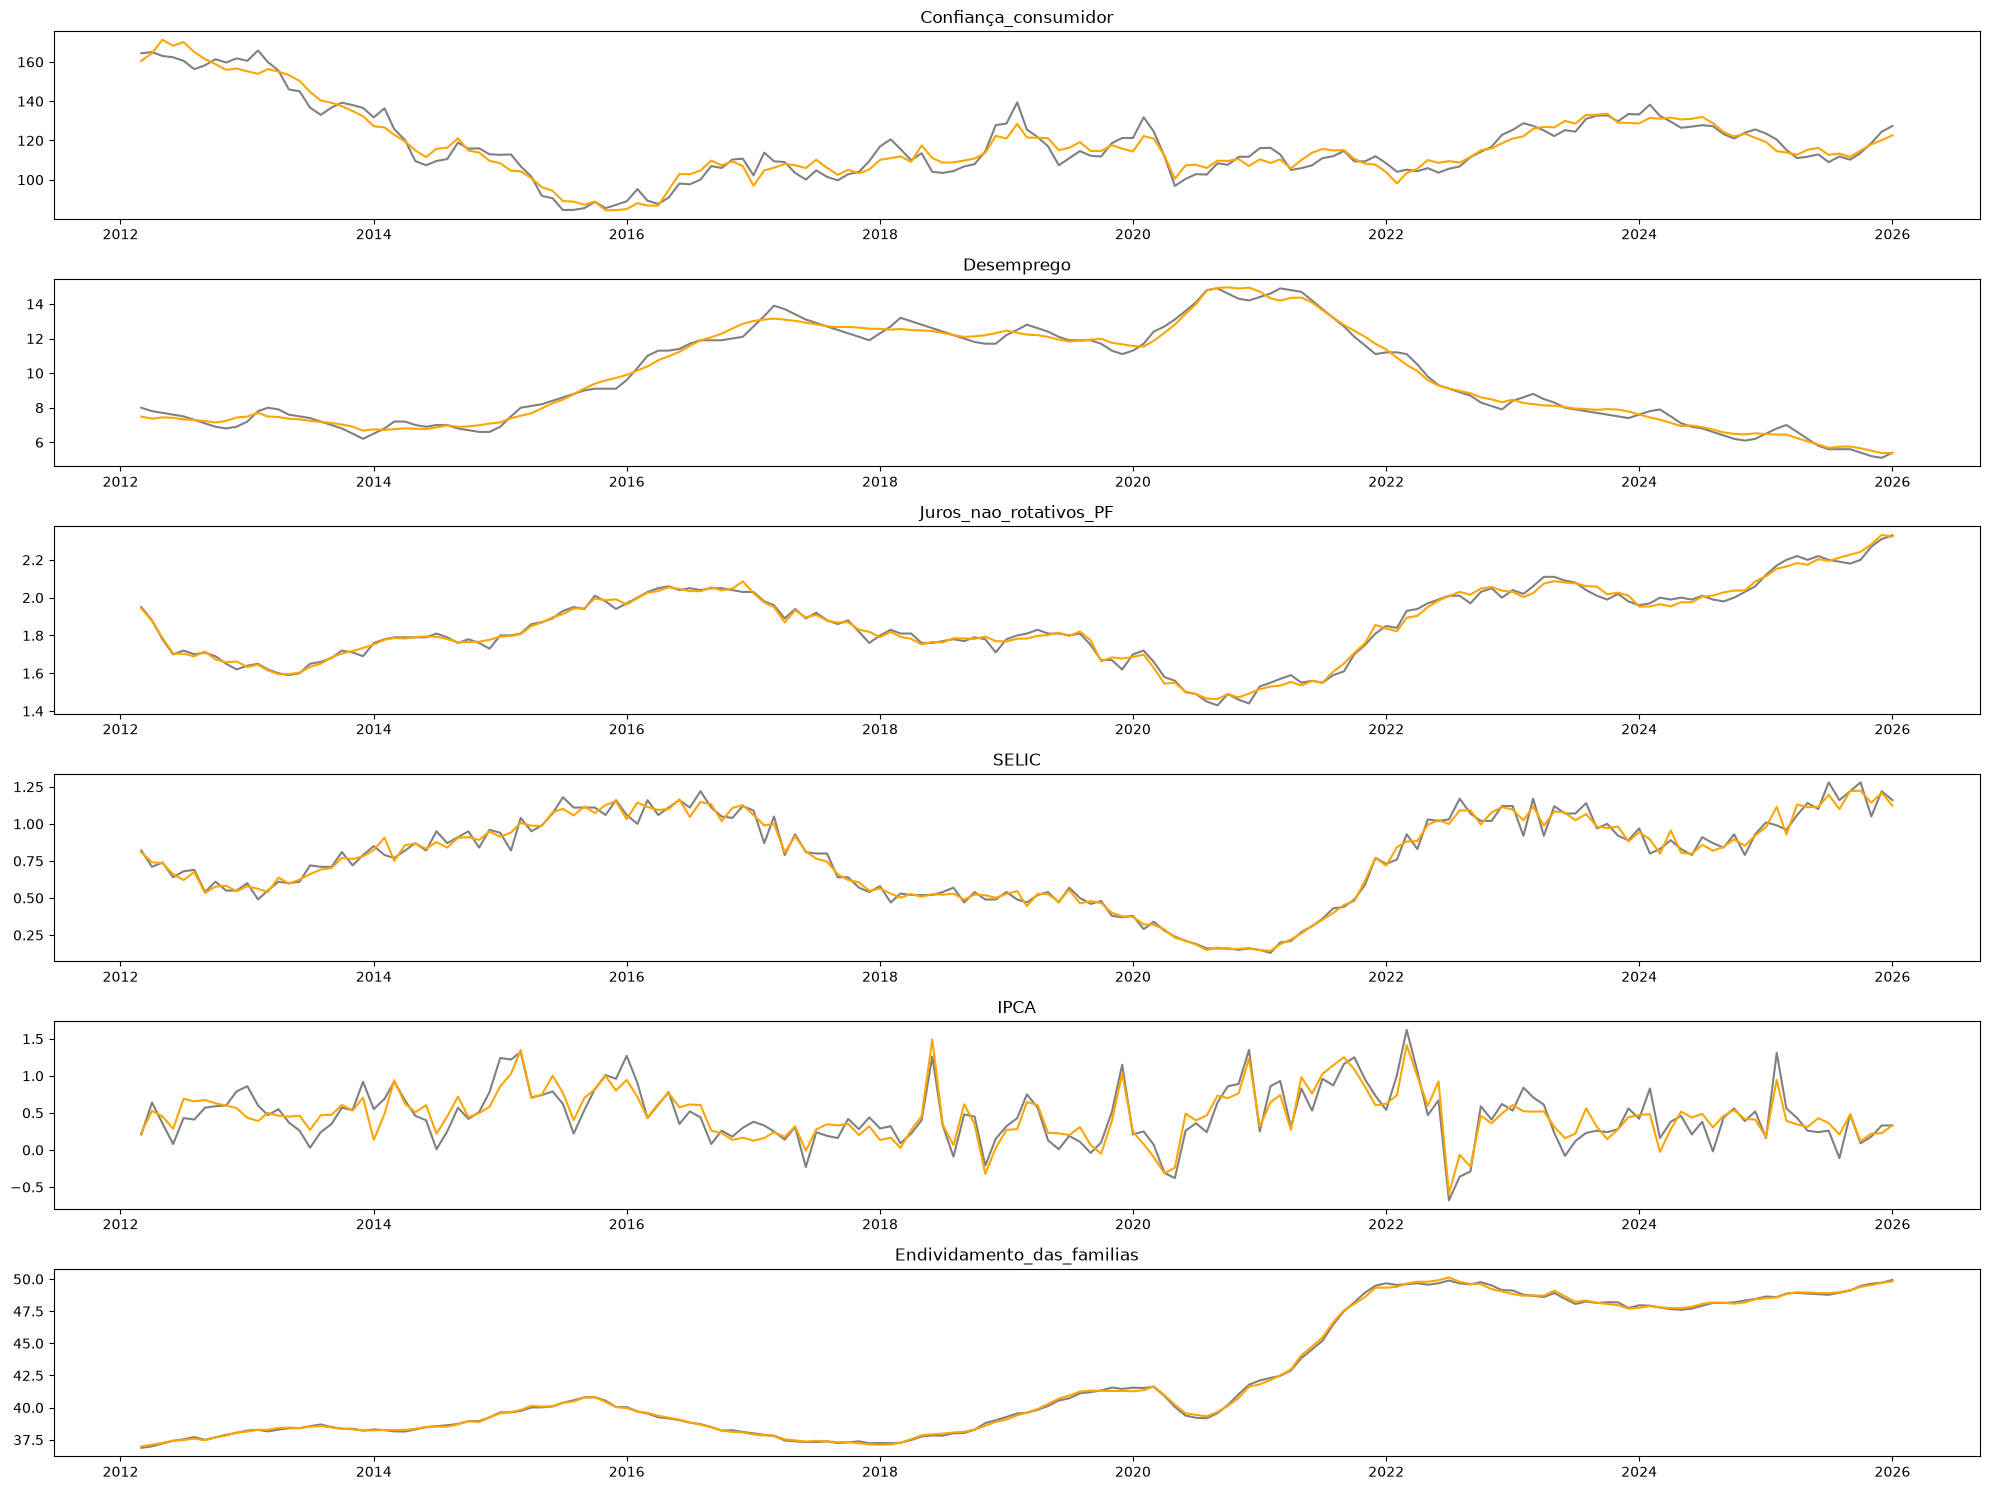

In [90]:
X13_PATH = "C:\\Users\\souza\\Downloads\\x13as_ascii-v1-1-b62 (1)\\x13as"
sazo_cols = ['Confiança_consumidor', 'Desemprego', 'Juros_nao_rotativos_PF', 'SELIC', 'IPCA', 'Endividamento_das_familias']
fig, axes = plt.subplots(len(sazo_cols), 1, figsize=(20,15))
for x13_cols, ax in zip(sazo_cols, axes):
    original = X_train[x13_cols]
    resultado = x13_arima_analysis(X_train[x13_cols], x12path=X13_PATH)
    X_train[x13_cols] = resultado.seasadj
    print(f'coluna {x13_cols} OK')
    ax.plot(original, label='original', color='grey')
    ax.plot(X_train[x13_cols], label='X-13 ARIMA SEATS', color='orange')
    ax.set_title(f'{x13_cols}')
    fig.tight_layout()
    
    

In [91]:
""""X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train = X_train.reset_index(drop=True)
X_train= X_train.drop(['data'], axis=1)
X_train.insert(0, 'intercepto',1)"""


'"X_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train = X_train.reset_index(drop=True)\nX_train= X_train.drop([\'data\'], axis=1)\nX_train.insert(0, \'intercepto\',1)'

In [92]:
#X_train = X_train.drop('index', axis=1)
""""
X_train = X_train.dropna()
X_train.to_csv(path_modelagem, sep=',', index=False)"""

'"\nX_train = X_train.dropna()\nX_train.to_csv(path_modelagem, sep=\',\', index=False)'

In [93]:
X_train

,Confiança_consumidor,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,,
2012-03-01,160.529429,7.487069,1.943800,0.807788,98.06309,0.231308,36.992347
2012-04-01,164.444413,7.366499,1.876279,0.741320,98.38205,0.527917,37.111279
2012-05-01,171.233812,7.443742,1.787110,0.734245,99.62478,0.454032,37.259476
2012-06-01,168.255341,7.412833,1.703733,0.659889,100.33945,0.285128,37.425464
2012-07-01,170.088473,7.332529,1.702827,0.621403,100.51105,0.689960,37.483668
...,...,...,...,...,...,...,...
2025-09-01,111.630952,5.755866,2.227493,1.221394,108.63642,0.478253,49.138474
2025-10-01,114.867233,5.654327,2.242185,1.224007,108.71590,0.116143,49.388298
2025-11-01,118.005736,5.515957,2.282040,1.142840,109.27405,0.219613,49.537583


<Axes: >

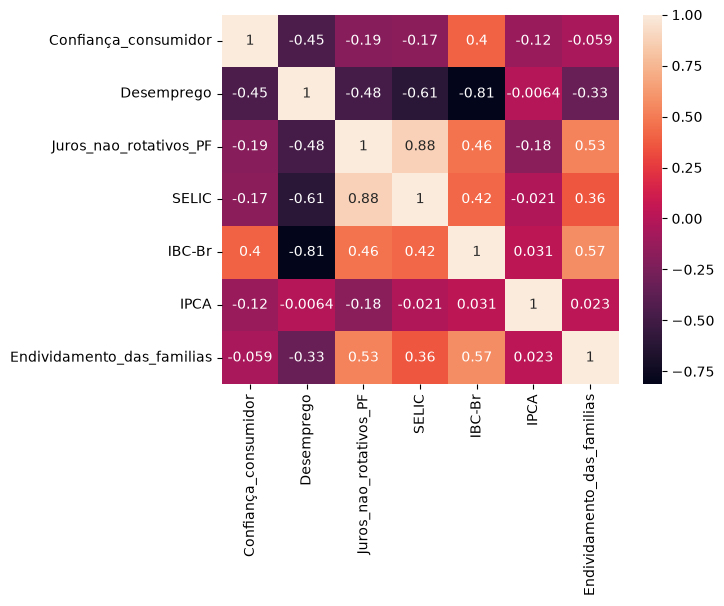

In [94]:
sns.heatmap(X_train.corr(), annot=True)

In [95]:
# funçao para calculo de vif
def vif_calculator(X:pd.DataFrame):
    vif_df = pd.DataFrame()
    vif_df['features'] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df

In [96]:
vif_calculator(X_train)

,features,VIF
0,Confiança_consumidor,87.781389
1,Desemprego,27.836511
2,Juros_nao_rotativos_PF,739.784721
3,SELIC,67.688648
4,IBC-Br,612.696330
5,IPCA,3.879545
6,Endividamento_das_familias,157.306298


In [97]:
# irei remover os juros nao rotativos para reduzir a redundancia 
X_train = X_train.drop('Juros_nao_rotativos_PF', axis=1)

In [98]:
# re-calculando vif
vif_calculator(X_train)

,features,VIF
0,Confiança_consumidor,87.743029
1,Desemprego,17.548799
2,SELIC,16.832157
3,IBC-Br,418.239025
4,IPCA,3.134490
5,Endividamento_das_familias,138.785301


O VIF caiu muito com a reduçao dos juros, porem, ainda há dados muito colineares entre si. Irei utilizar da variaçao logaritimica em IBC-Br

In [99]:
# funçao de diferença logaritmica
def log_diff(X:pd.Series):
    return np.log(X).diff()

In [100]:
X_train['IBC-Br'] = log_diff(X_train['IBC-Br'])

In [101]:
X_train

,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
data,,,,,,
2012-03-01,160.529429,7.487069,0.807788,NaN,0.231308,36.992347
2012-04-01,164.444413,7.366499,0.741320,0.003247,0.527917,37.111279
2012-05-01,171.233812,7.443742,0.734245,0.012553,0.454032,37.259476
2012-06-01,168.255341,7.412833,0.659889,0.007148,0.285128,37.425464
2012-07-01,170.088473,7.332529,0.621403,0.001709,0.689960,37.483668
...,...,...,...,...,...,...
2025-09-01,111.630952,5.755866,1.221394,-0.001507,0.478253,49.138474
2025-10-01,114.867233,5.654327,1.224007,0.000731,0.116143,49.388298
2025-11-01,118.005736,5.515957,1.142840,0.005121,0.219613,49.537583


Aplicando Log para confiança

In [102]:
X_train['Confiança_consumidor'] = log_diff(X_train['Confiança_consumidor'])

In [103]:
vif_calculator(X_train.dropna())

,features,VIF
0,Confiança_consumidor,1.042423
1,Desemprego,12.740198
2,SELIC,11.908581
3,IBC-Br,1.038122
4,IPCA,3.025295
5,Endividamento_das_familias,35.051606


In [104]:
vif_calculator(X_train.dropna())

,features,VIF
0,Confiança_consumidor,1.042423
1,Desemprego,12.740198
2,SELIC,11.908581
3,IBC-Br,1.038122
4,IPCA,3.025295
5,Endividamento_das_familias,35.051606


In [105]:
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train = X_train.reset_index(drop=True)
X_train= X_train.drop(['data'], axis=1)
X_train.insert(0, 'intercepto',1)

In [106]:
X_train = X_train.dropna()
X_train.to_csv(path_modelagem, sep=',', index=False)

In [107]:
X_train.shape

(166, 7)

In [108]:
X_train

,intercepto,Confiança_consumidor,Desemprego,SELIC,IBC-Br,IPCA,Endividamento_das_familias
1,1,0.024095,7.366499,0.741320,0.003247,0.527917,37.111279
2,1,0.040457,7.443742,0.734245,0.012553,0.454032,37.259476
3,1,-0.017547,7.412833,0.659889,0.007148,0.285128,37.425464
4,1,0.010836,7.332529,0.621403,0.001709,0.689960,37.483668
5,1,-0.029887,7.280069,0.674989,0.002983,0.656219,37.587446
...,...,...,...,...,...,...,...
162,1,-0.014982,5.755866,1.221394,-0.001507,0.478253,49.138474
163,1,0.028579,5.654327,1.224007,0.000731,0.116143,49.388298
164,1,0.026956,5.515957,1.142840,0.005121,0.219613,49.537583
165,1,0.017922,5.372552,1.209036,0.001313,0.226347,49.701265


In [109]:
vif_calculator(X_train)

,features,VIF
0,intercepto,151.982666
1,Confiança_consumidor,1.072306
2,Desemprego,1.706445
3,SELIC,1.718341
4,IBC-Br,1.035884
5,IPCA,1.013989
6,Endividamento_das_familias,1.189205


In [111]:
# exportando X_train para avaliaçao do modelo 
x_train_path = os.path.join('..', 'data', 'processed', 'dados_treino.csv')
X_train.to_csv(x_train_path, index=False)

In [114]:
X_train.shape

(166, 7)

In [116]:
y_train_path = os.path.join('..', 'data', 'processed', 'vetor_resposta.csv')
y_train.to_csv(y_train_path)
